# Phase 2 — Task 6: NorthStar Monthly Report Analysis

Before creating the report, I ran this monthly report anslysis, comparing December 2024 with November 2024, using all of my Phase 2 work: dataset/northstar_clean.csv, the merged regions, my pandas and SQL analyses. 

The numbers used in `northstar_monthly_report` is computed here. 

**Period covered:** December 2024, compared with November 2024.

In [1]:
# Load the cleaned orders and the regions reference table. sqlite3 is
# needed later for the SQL cross-check.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sqlite3

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv('../../dataset/northstar_clean.csv')
regions_ref = pd.read_csv('../../dataset/northstar_regions.csv')

print(f"Loaded {len(df):,} order rows and {len(regions_ref)} regions reference rows.")

Loaded 999 order rows and 8 regions reference rows.


All four Phase 2 data sources: the cleaned order table, the regions table (merged in below), pandas for the analysis, and a SQL check at the end of Section 2.

In [2]:
# Merge regional_manager and country onto every order. 
df = df.merge(regions_ref[['region', 'regional_manager', 'country']], on='region', how='left')

n_unmatched = df['regional_manager'].isna().sum()
print(f"Orders with no matching region after the merge: {n_unmatched}")
assert n_unmatched == 0, "Region merge left unmatched rows, check casing."
df[['order_id', 'region', 'regional_manager', 'country']].head()

Orders with no matching region after the merge: 0


,order_id,region,regional_manager,country
0,NS-00522,West,Daniel Hughes,England
1,NS-00740,London,Olivia Clarke,England
2,NS-00824,Scotland,Fiona MacLeod,Scotland
3,NS-00663,London,Olivia Clarke,England
4,NS-00412,Midlands,Mohammed Iqbal,England


## 1. Preparation

Same casing fixes as Task 2, and order_date parsed to a real datetime.

In [3]:
# Parse order_date and reapply the Task 2 casing fixes for region and
# payment_method.
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['region'] = df['region'].str.strip().str.title()

payment_map = {'card': 'Card', 'cash': 'Cash', 'paypal': 'PayPal', 'bank transfer': 'Bank Transfer'}
df['payment_method'] = df['payment_method'].apply(
    lambda v: v if v == 'Unknown' else payment_map.get(str(v).strip().lower(), v)
)

n_missing_date = df['order_date'].isna().sum()
print(f"Rows with a missing order_date (excluded from date-based analysis): {n_missing_date}")
df.loc[df['order_date'].isna(), ['order_id', 'region']]

Rows with a missing order_date (excluded from date-based analysis): 0


,order_id,region


In [4]:
# Everything date-based from here on uses this filtered frame.
df_dated = df[df['order_date'].notna()].copy()
print(f"Rows available for date-based analysis: {len(df_dated):,}")

Rows available for date-based analysis: 999


In [5]:
# The two months being compared.
nov = df_dated[(df_dated['order_date'] >= '2024-11-01') & (df_dated['order_date'] < '2024-12-01')].copy()
dec = df_dated[(df_dated['order_date'] >= '2024-12-01') & (df_dated['order_date'] < '2025-01-01')].copy()

print(f"November 2024: {len(nov)} orders")
print(f"December 2024: {len(dec)} orders")

November 2024: 67 orders
December 2024: 90 orders


## 2. Headline: December revenue vs November

In [6]:
# The main number the report leads with.
nov_revenue = nov['total_amount'].sum()
dec_revenue = dec['total_amount'].sum()
mom_pct_change = (dec_revenue - nov_revenue) / nov_revenue * 100

print(f"November revenue: £{nov_revenue:,.2f}")
print(f"December revenue: £{dec_revenue:,.2f}")
print(f"Month-over-month change: {mom_pct_change:+.2f}%")

November revenue: £36,954.95
December revenue: £52,499.40
Month-over-month change: +42.06%


In [7]:
# A few supporting numbers behind the headline: did more customers order,
# and did they spend more per order.
dec_unique_customers = dec['customer_id'].nunique()
nov_unique_customers = nov['customer_id'].nunique()
dec_aov = dec['total_amount'].mean()
nov_aov = nov['total_amount'].mean()
dec_basket = dec['quantity'].mean()
nov_basket = nov['quantity'].mean()

print(f"Unique customers: Nov {nov_unique_customers} -> Dec {dec_unique_customers} "
      f"({(dec_unique_customers-nov_unique_customers)/nov_unique_customers*100:+.1f}%)")
print(f"Average order value: Nov £{nov_aov:.2f} -> Dec £{dec_aov:.2f} "
      f"({(dec_aov-nov_aov)/nov_aov*100:+.1f}%)")
print(f"Average basket size: Nov {nov_basket:.2f} -> Dec {dec_basket:.2f} units")

Unique customers: Nov 61 -> Dec 80 (+31.1%)
Average order value: Nov £551.57 -> Dec £583.33 (+5.8%)
Average basket size: Nov 5.40 -> Dec 5.79 units


In [8]:
# Full year of revenue, so December can be judged against the normal
# range instead of in isolation.
monthly_revenue = df_dated.set_index('order_date')['total_amount'].resample('ME').sum().round(2)
monthly_revenue.index = monthly_revenue.index.strftime('%b %Y')
monthly_revenue

order_date
Jan 2024    35794.90
Feb 2024    51531.66
Mar 2024    31633.94
Apr 2024    41338.34
May 2024    34148.40
Jun 2024    50528.45
Jul 2024    40509.56
Aug 2024    45715.46
Sep 2024    39847.09
Oct 2024    53116.90
Nov 2024    36954.95
Dec 2024    52499.40
Name: total_amount, dtype: float64

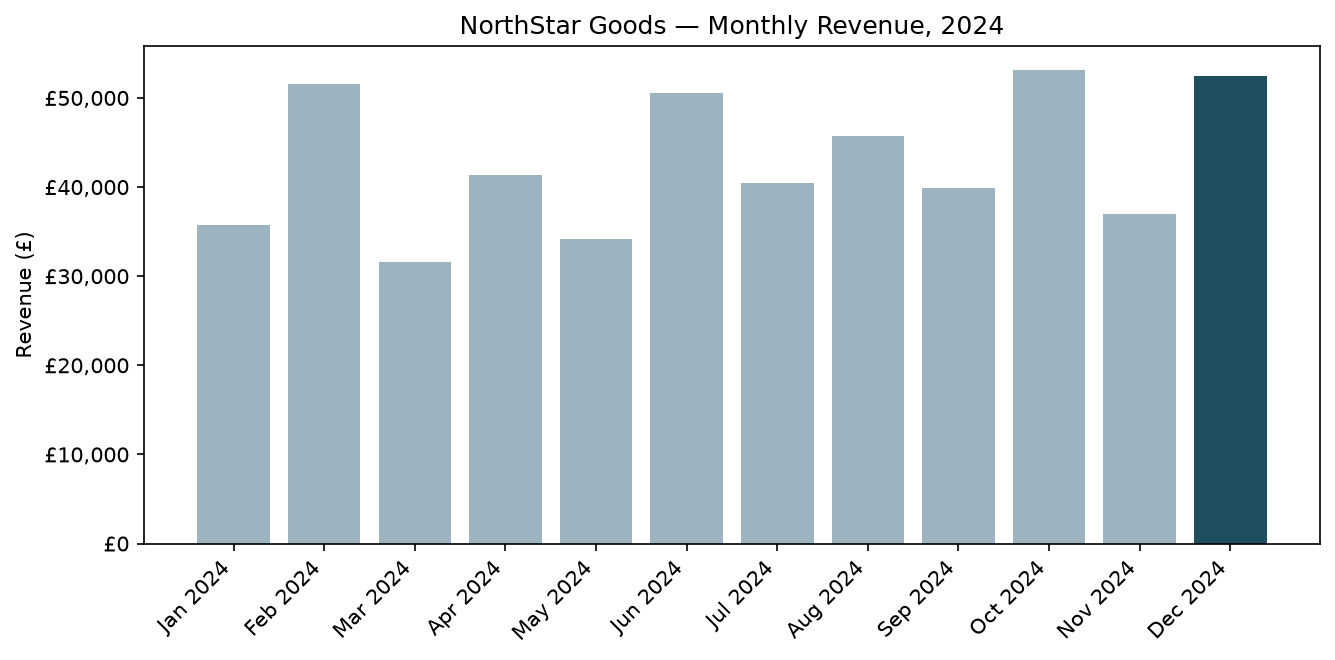

In [9]:
# CHART 1: monthly revenue for the year, December picked out in a
# darker colour.
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#9db4c0' if m != 'Dec 2024' else '#1f4e5f' for m in monthly_revenue.index]
bars = ax.bar(monthly_revenue.index, monthly_revenue.values, color=colors)
ax.set_title('NorthStar Goods — Monthly Revenue, 2024')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=200, bbox_inches='tight')
plt.show()

**Note:** December 2024 revenue is £52,499.40, the second-highest month of the year after October (£53,116.90), and 42.06% above November. November was the second-lowest month of the year, so part of December's jump is a recovery from a weak prior month, not a new high.

### SQL cross-check

This recomputes the two headline revenue numbers directly against the Task 4/5 database, separately from the pandas code above, to check they agree.

In [10]:
# Independent check: same two numbers, computed with SQL instead of
# pandas, against the actual database.
conn = sqlite3.connect('northstar.db')
cur = conn.cursor()

cur.execute("""
    SELECT ROUND(SUM(total_amount), 2) FROM orders
    WHERE order_date >= '2024-11-01' AND order_date < '2024-12-01'
""")
sql_nov_revenue = cur.fetchone()[0]

cur.execute("""
    SELECT ROUND(SUM(total_amount), 2) FROM orders
    WHERE order_date >= '2024-12-01' AND order_date < '2025-01-01'
""")
sql_dec_revenue = cur.fetchone()[0]

conn.close()

print(f"November revenue, pandas: £{nov_revenue:,.2f}  |  SQL: £{sql_nov_revenue:,.2f}")
print(f"December revenue, pandas: £{dec_revenue:,.2f}  |  SQL: £{sql_dec_revenue:,.2f}")

assert round(nov_revenue, 2) == sql_nov_revenue, "pandas and SQL November totals disagree."
assert round(dec_revenue, 2) == sql_dec_revenue, "pandas and SQL December totals disagree."
print("Confirmed: pandas and SQL agree exactly on both months.")

November revenue, pandas: £36,954.95  |  SQL: £36,954.95
December revenue, pandas: £52,499.40  |  SQL: £52,499.40
Confirmed: pandas and SQL agree exactly on both months.


## 3. Which categories drove or dragged revenue

In [11]:
# Revenue by category, both months, side by side.
cat_nov = nov.groupby('product_category')['total_amount'].sum()
cat_dec = dec.groupby('product_category')['total_amount'].sum()

category_compare = pd.DataFrame({'nov_revenue': cat_nov, 'dec_revenue': cat_dec}).fillna(0)
category_compare['change'] = category_compare['dec_revenue'] - category_compare['nov_revenue']
category_compare['pct_change'] = (
    category_compare['change'] / category_compare['nov_revenue'].replace(0, np.nan) * 100
).round(2)
category_compare = category_compare.round(2).sort_values('change', ascending=False)
category_compare

,nov_revenue,dec_revenue,change,pct_change
product_category,,,,
Electronics,4996.05,11531.56,6535.51,130.81
Beauty,3874.98,8971.45,5096.47,131.52
Food & Drink,1135.83,5058.64,3922.81,345.37
Toys,2998.81,6008.39,3009.58,100.36
Home & Garden,3558.37,4576.87,1018.50,28.62
Clothing,7789.28,7903.54,114.26,1.47
Sports,12601.63,8448.95,-4152.68,-32.95


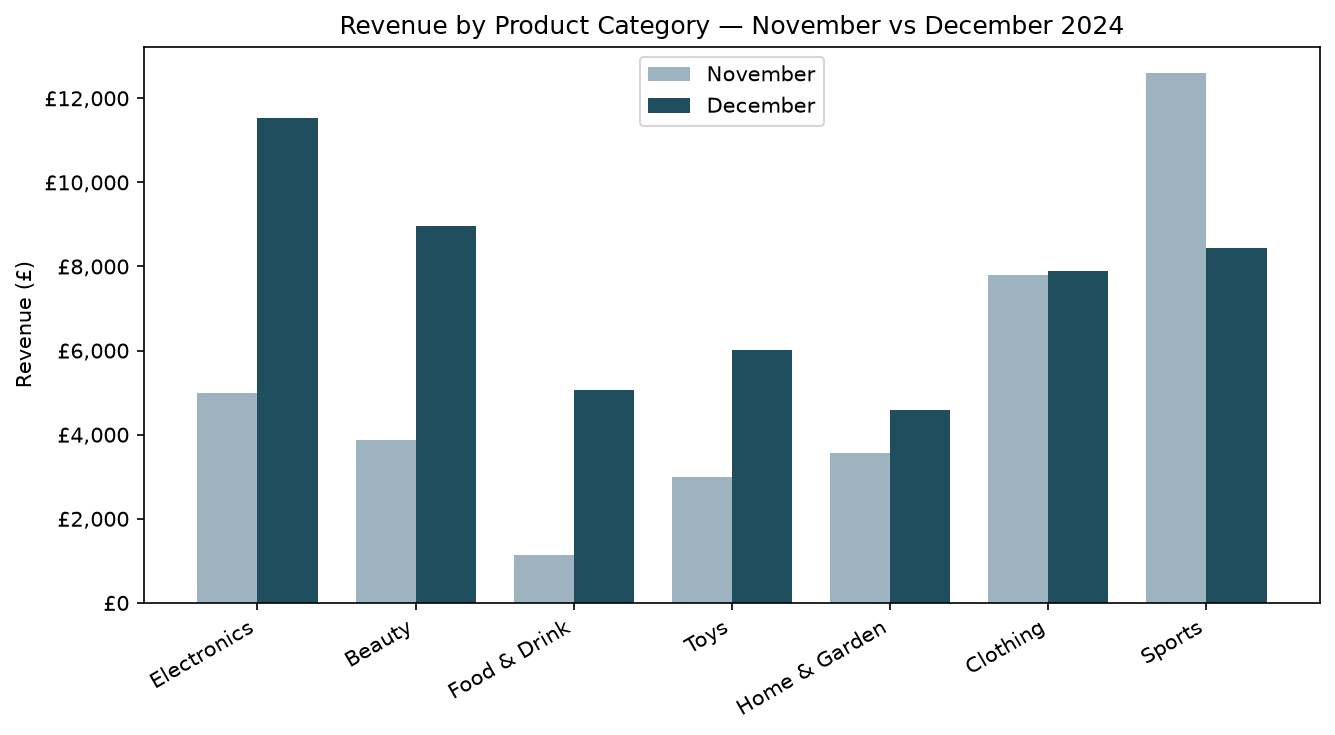

In [12]:
# CHART 2: grouped bars, November vs December, one pair per category.
fig, ax = plt.subplots(figsize=(9, 5))
order = category_compare.index
x = np.arange(len(order))
width = 0.38

ax.bar(x - width/2, category_compare.loc[order, 'nov_revenue'], width, label='November', color='#9db4c0')
ax.bar(x + width/2, category_compare.loc[order, 'dec_revenue'], width, label='December', color='#1f4e5f')

ax.set_title('Revenue by Product Category — November vs December 2024')
ax.set_ylabel('Revenue (£)')
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('chart2_category_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

**Note:** Electronics (+£6,535.51, +130.8%), Beauty (+£5,096.47, +131.5%), and Food & Drink (+£3,922.81, +345.4%) drove the December uplift. Sports was the only category to fall, down £4,152.68 (-33.0%) on November. Clothing was basically flat (+1.5%).

## 4. Which regions over- or under-performed vs target

Target is each region's November revenue times 1.05, a 5% growth target, as set out in the brief.

In [13]:
# Revenue by region, both months, plus a 5% target and whether each
# region hit it.
rev_nov_region = nov.groupby('region')['total_amount'].sum()
rev_dec_region = dec.groupby('region')['total_amount'].sum()

region_compare = pd.DataFrame({'nov_revenue': rev_nov_region, 'dec_revenue': rev_dec_region}).fillna(0)
region_compare['target'] = region_compare['nov_revenue'] * 1.05
region_compare['vs_target'] = region_compare['dec_revenue'] - region_compare['target']
region_compare['vs_target_pct'] = (region_compare['vs_target'] / region_compare['target'] * 100).round(2)

# Pull in the regional manager from the merged table, so the worst region
# can be tied to an actual name in the recommendations.
manager_lookup = regions_ref.set_index('region')['regional_manager']
region_compare['regional_manager'] = manager_lookup

region_compare = region_compare.round(2).sort_values('vs_target_pct', ascending=False)
region_compare

,nov_revenue,dec_revenue,target,vs_target,vs_target_pct,regional_manager
region,,,,,,
Wales,1657.81,8707.49,1740.70,6966.79,400.23,Rhys Davies
South,4423.07,8240.92,4644.22,3596.70,77.44,James Bennett
London,3751.87,5872.55,3939.46,1933.09,49.07,Olivia Clarke
North,5724.00,8815.72,6010.20,2805.52,46.68,Sarah Whitfield
Midlands,2806.69,3486.42,2947.02,539.40,18.30,Mohammed Iqbal
West,5513.24,6386.22,5788.90,597.32,10.32,Daniel Hughes
East,6013.49,5683.28,6314.16,-630.88,-9.99,Priya Sharma
Scotland,7064.78,5306.80,7418.02,-2111.22,-28.46,Fiona MacLeod


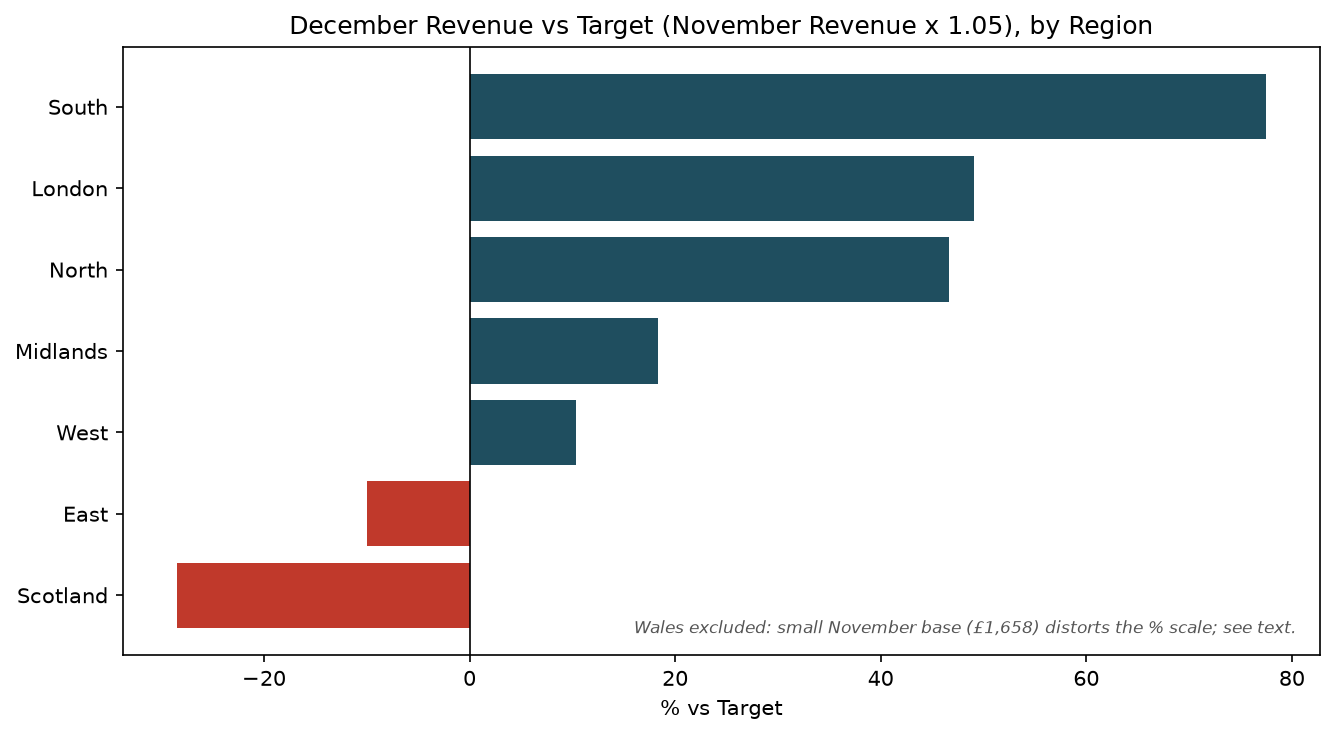

In [14]:
# CHART 3: how far each region is from target, as a percentage.
# Wales is left out of the chart (but stays in the table above and gets
# explained in text) because its November revenue was only £1,657.81,
# so its +400% bar would squash every other region's bar flat.
chart_data = region_compare.drop(index='Wales').sort_values('vs_target_pct')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c0392b' if v < 0 else '#1f4e5f' for v in chart_data['vs_target_pct']]
ax.barh(chart_data.index, chart_data['vs_target_pct'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('December Revenue vs Target (November Revenue x 1.05), by Region')
ax.set_xlabel('% vs Target')
ax.text(0.98, 0.03, 'Wales excluded: small November base (£1,658) distorts the % scale; see text.',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, style='italic', color='#555555')
plt.tight_layout()
plt.savefig('chart3_region_vs_target.png', dpi=200, bbox_inches='tight')
plt.show()

In [16]:
# Placing this on its own so it's easy to find when writing the
# recommendation about Scotland.
scotland_manager = manager_lookup['Scotland']
print(f"Scotland's regional manager (from the merged regions table): {scotland_manager}")

Scotland's regional manager (from the merged regions table): Fiona MacLeod


**Note:** 6 of 8 regions cleared target. Scotland (-28.5%) and East (-10.0%) missed. Wales looks like it beat target by over 400%, but that's a small-base effect, its November revenue was only £1,657.81, the lowest of any region, so a 5% target on that is trivial to clear. Shouldn't be read as a real success without more data. Scotland's manager, Fiona MacLeod, gets named directly in the recommendations, which only works because the regions table was merged in.

## 5. Day-of-week / seasonal pattern

In [17]:
# How December's revenue breaks down by day of week.
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dec_dow = dec.copy()
dec_dow['day_of_week'] = dec_dow['order_date'].dt.day_name()
dec_dow_summary = dec_dow.groupby('day_of_week')['total_amount'].agg(['sum', 'count']).reindex(dow_order).round(2)
dec_dow_summary

,sum,count
day_of_week,,
Monday,6995.36,17
Tuesday,7043.75,11
Wednesday,7334.85,12
Thursday,8293.26,13
Friday,6241.40,10
Saturday,7945.04,13
Sunday,8645.74,14


In [19]:
# Same day of week breakdown but across the whole year, to check if December's
# pattern is real or just noise from a small sample.
df_dow = df_dated.copy()
df_dow['day_of_week'] = df_dow['order_date'].dt.day_name()
full_year_dow = df_dow.groupby('day_of_week')['total_amount'].agg(['sum', 'count', 'mean']).reindex(dow_order).round(2)
full_year_dow

,sum,count,mean
day_of_week,,,
Monday,76137.69,142,536.18
Tuesday,61957.01,119,520.65
Wednesday,76711.80,153,501.38
Thursday,81750.89,150,545.01
Friday,71990.50,135,533.26
Saturday,75026.01,155,484.04
Sunday,70045.15,145,483.07


**Note:** December's revenue by day of week goes from £6,241 (Friday) to £8,646 (Sunday), but that's only 90 orders spread across 7 days, about 13 a day. The full year (999 orders) is basically flat, £483 to £545 per order no matter the day. So December's swing is most likely just noise from a small sample, not a real pattern, and no chart or action is included here on that basis.

## 6. Return rate — first look

`returned` becomes the model target in Phase 4. This is just a first descriptive look, nothing more.

In [20]:
# Overall return rate for each period, for comparison.
dec_return_rate = (dec['returned'] == 'Y').mean() * 100
nov_return_rate = (nov['returned'] == 'Y').mean() * 100
full_year_return_rate = (df_dated['returned'] == 'Y').mean() * 100

print(f"December return rate: {dec_return_rate:.1f}% ({len(dec)} orders)")
print(f"November return rate: {nov_return_rate:.1f}% ({len(nov)} orders)")
print(f"Full-year return rate: {full_year_return_rate:.1f}% ({len(df_dated)} orders)")

December return rate: 25.6% (90 orders)
November return rate: 17.9% (67 orders)
Full-year return rate: 23.8% (999 orders)


In [21]:
# Return rate split by category, with order count alongside so the
# reader can see how much data each rate is based on.
return_by_category = dec.groupby('product_category')['returned'].apply(lambda s: (s == 'Y').mean() * 100).round(1)
n_by_category = dec.groupby('product_category').size()
return_cat_table = pd.DataFrame({'return_rate_pct': return_by_category, 'n_orders': n_by_category})
return_cat_table = return_cat_table.sort_values('return_rate_pct', ascending=False)
return_cat_table

,return_rate_pct,n_orders
product_category,,
Clothing,50.0,10
Home & Garden,33.3,9
Electronics,30.0,20
Food & Drink,25.0,8
Toys,22.2,9
Beauty,18.8,16
Sports,11.1,18


In [22]:
# Same thing, split by region instead.
return_by_region = dec.groupby('region')['returned'].apply(lambda s: (s == 'Y').mean() * 100).round(1)
n_by_region = dec.groupby('region').size()
return_region_table = pd.DataFrame({'return_rate_pct': return_by_region, 'n_orders': n_by_region})
return_region_table = return_region_table.sort_values('return_rate_pct', ascending=False)
return_region_table

,return_rate_pct,n_orders
region,,
Scotland,37.5,8
Midlands,33.3,6
South,31.2,16
North,30.8,13
London,27.3,11
East,25.0,12
West,14.3,14
Wales,10.0,10


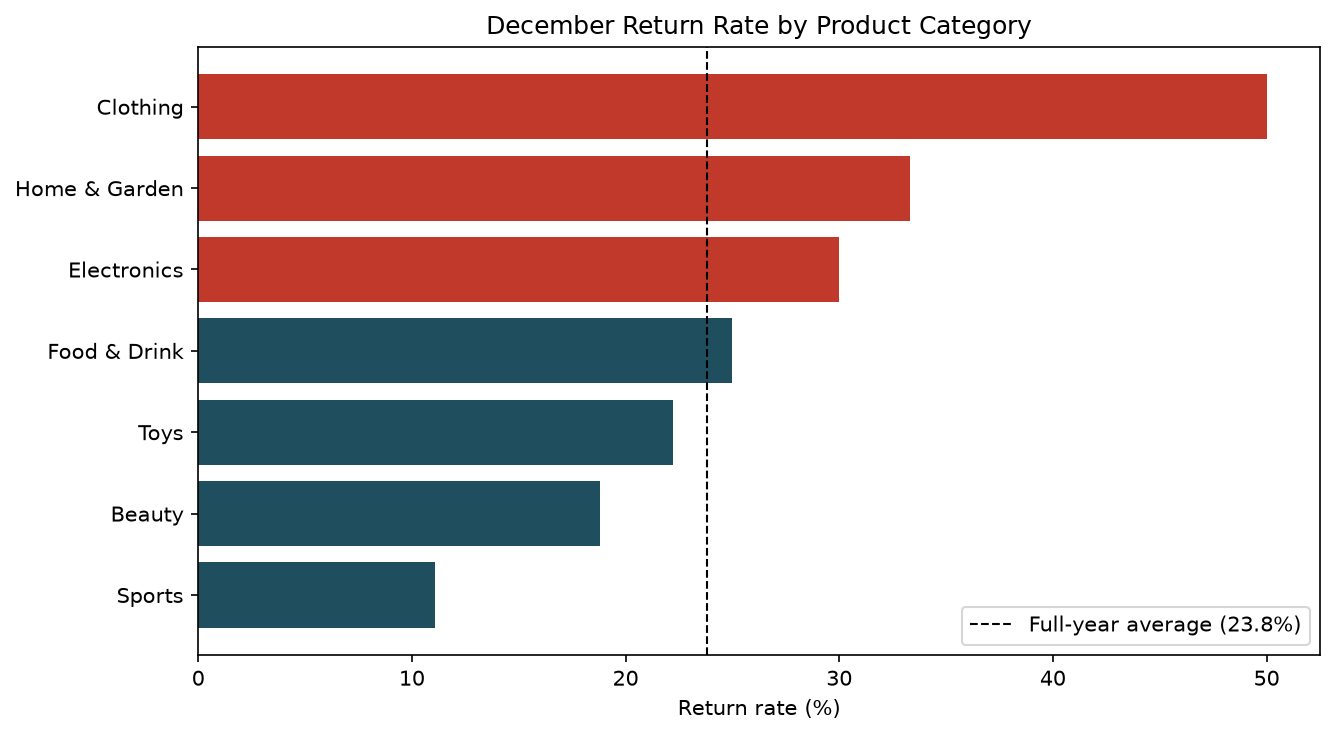

In [23]:
# CHART 4: return rate by category, with the full-year average marked
# as a reference line.
fig, ax = plt.subplots(figsize=(9, 5))
order = return_cat_table.sort_values('return_rate_pct').index
colors = ['#c0392b' if v >= 30 else '#1f4e5f' for v in return_cat_table.loc[order, 'return_rate_pct']]
ax.barh(order, return_cat_table.loc[order, 'return_rate_pct'], color=colors)
ax.axvline(full_year_return_rate, color='black', linestyle='--', linewidth=1,
           label=f'Full-year average ({full_year_return_rate:.1f}%)')
ax.set_title('December Return Rate by Product Category')
ax.set_xlabel('Return rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('chart4_return_rate_category.png', dpi=200, bbox_inches='tight')
plt.show()

**Note:** December's overall return rate is 25.6%, above both November's 17.9% and the full-year average of 23.8%. By category, Clothing is highest at 50.0% (5 of 10 orders), small sample though. Sports is lowest at 11.1%. By region, Scotland is highest at 37.5% (only 8 orders) and Wales lowest at 10.0%. All of these region and category numbers are based on small counts (8 to 20 orders), so they're worth watching, not proof of anything yet.

## 7. Summary table of every figure used in the report

In [24]:
# Everything the report quotes, in one place, so it's easy to check
# nothing drifted between here and the final write-up.
summary = {
    "November revenue": f"£{nov_revenue:,.2f}",
    "December revenue": f"£{dec_revenue:,.2f}",
    "MoM revenue change": f"{mom_pct_change:+.2f}%",
    "December unique customers": dec_unique_customers,
    "November unique customers": nov_unique_customers,
    "December AOV": f"£{dec_aov:,.2f}",
    "November AOV": f"£{nov_aov:,.2f}",
    "Top growth category": "Food & Drink (+345.4%)",
    "Only category to fall": "Sports (-33.0%)",
    "Regions missing target": "Scotland (-28.5%), East (-10.0%)",
    "December return rate": f"{dec_return_rate:.1f}%",
    "November return rate": f"{nov_return_rate:.1f}%",
    "Full-year return rate": f"{full_year_return_rate:.1f}%",
    "Highest-return category": "Clothing (50.0%)",
    "Lowest-return category": "Sports (11.1%)",
    "Scotland regional manager": scotland_manager,
    "SQL cross-check": "pandas and SQL agree exactly on Nov/Dec revenue",
}
for k, v in summary.items():
    print(f"{k}: {v}")

November revenue: £36,954.95
December revenue: £52,499.40
MoM revenue change: +42.06%
December unique customers: 80
November unique customers: 61
December AOV: £583.33
November AOV: £551.57
Top growth category: Food & Drink (+345.4%)
Only category to fall: Sports (-33.0%)
Regions missing target: Scotland (-28.5%), East (-10.0%)
December return rate: 25.6%
November return rate: 17.9%
Full-year return rate: 23.8%
Highest-return category: Clothing (50.0%)
Lowest-return category: Sports (11.1%)
Scotland regional manager: Fiona MacLeod
SQL cross-check: pandas and SQL agree exactly on Nov/Dec revenue
